In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_results = pd.read_csv("./models/model_results.csv")


# Model Comparision plot

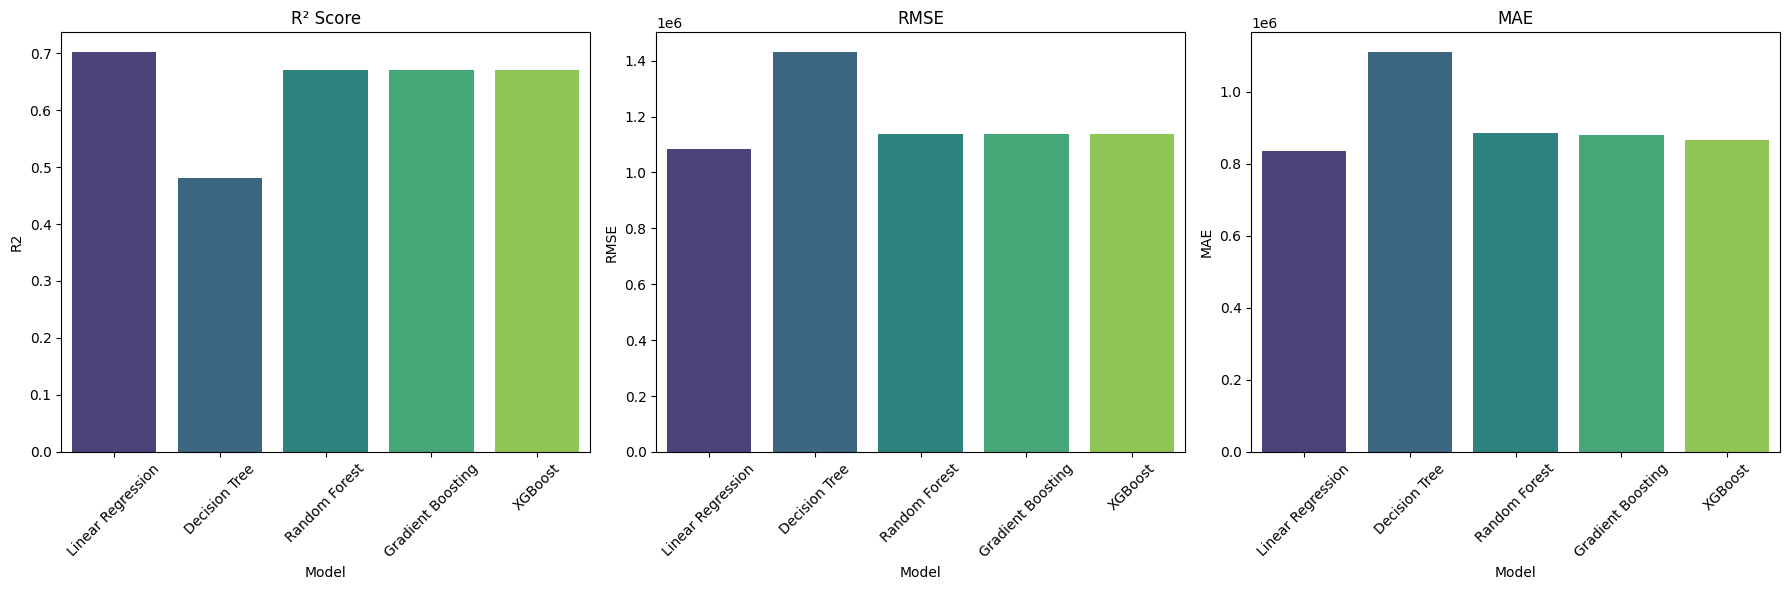

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# R²
sns.barplot(
    data=model_results,
    x='Model',
    y='R2',
    palette='viridis',
    hue='Model',
    ax=axes[0]
)
axes[0].set_title('R² Score')

# RMSE
sns.barplot(
    data=model_results,
    x='Model',
    y='RMSE',
    palette='viridis',
    hue='Model',
    ax=axes[1]
)
axes[1].set_title('RMSE')

# MAE
sns.barplot(
    data=model_results,
    x='Model',
    y='MAE',
    palette='viridis',
    hue='Model',
    ax=axes[2]
)
axes[2].set_title('MAE')

# Rotate model names if needed
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# Actual vs Predicted Scatter Plot

In [9]:
def plot_regression_diagnostics(df, model_name):
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    # Actual vs Predicted
    sns.scatterplot(
        x=df['Actual_Price'],
        y=df['Predicted_Price'],
        alpha=0.6,
        ax=axes[0]
    )

    min_val = min(df['Actual_Price'].min(), df['Predicted_Price'].min())
    max_val = max(df['Actual_Price'].max(), df['Predicted_Price'].max())

    axes[0].plot(
        [min_val, max_val],
        [min_val, max_val],
        'r--',
        label='Perfect Prediction'
    )

    axes[0].set_title(f'{model_name}: Actual vs Predicted')
    axes[0].set_xlabel('Actual Prices')
    axes[0].set_ylabel('Predicted Prices')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.4)

    # Residual Plot
    sns.scatterplot(
        x=df['Predicted_Price'],
        y=df['Residual'],
        alpha=0.5,
        ax=axes[1]
    )

    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title('Residual Plot')
    axes[1].set_xlabel('Predicted Prices')
    axes[1].set_ylabel('Residuals')
    axes[1].grid(True, alpha=0.3)

    # Residual Distribution
    sns.histplot(df['Residual'], kde=True, ax=axes[2])
    axes[2].set_title('Residual Distribution')
    axes[2].set_xlabel('Residual')

    # Absolute Error Distribution
    sns.histplot(df['Absolute_Error'], kde=True, ax=axes[3])
    axes[3].set_title('Absolute Error Distribution')
    axes[3].set_xlabel('Absolute Error')

    fig.suptitle(f'{model_name} Regression Diagnostics', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


## Linear Regression

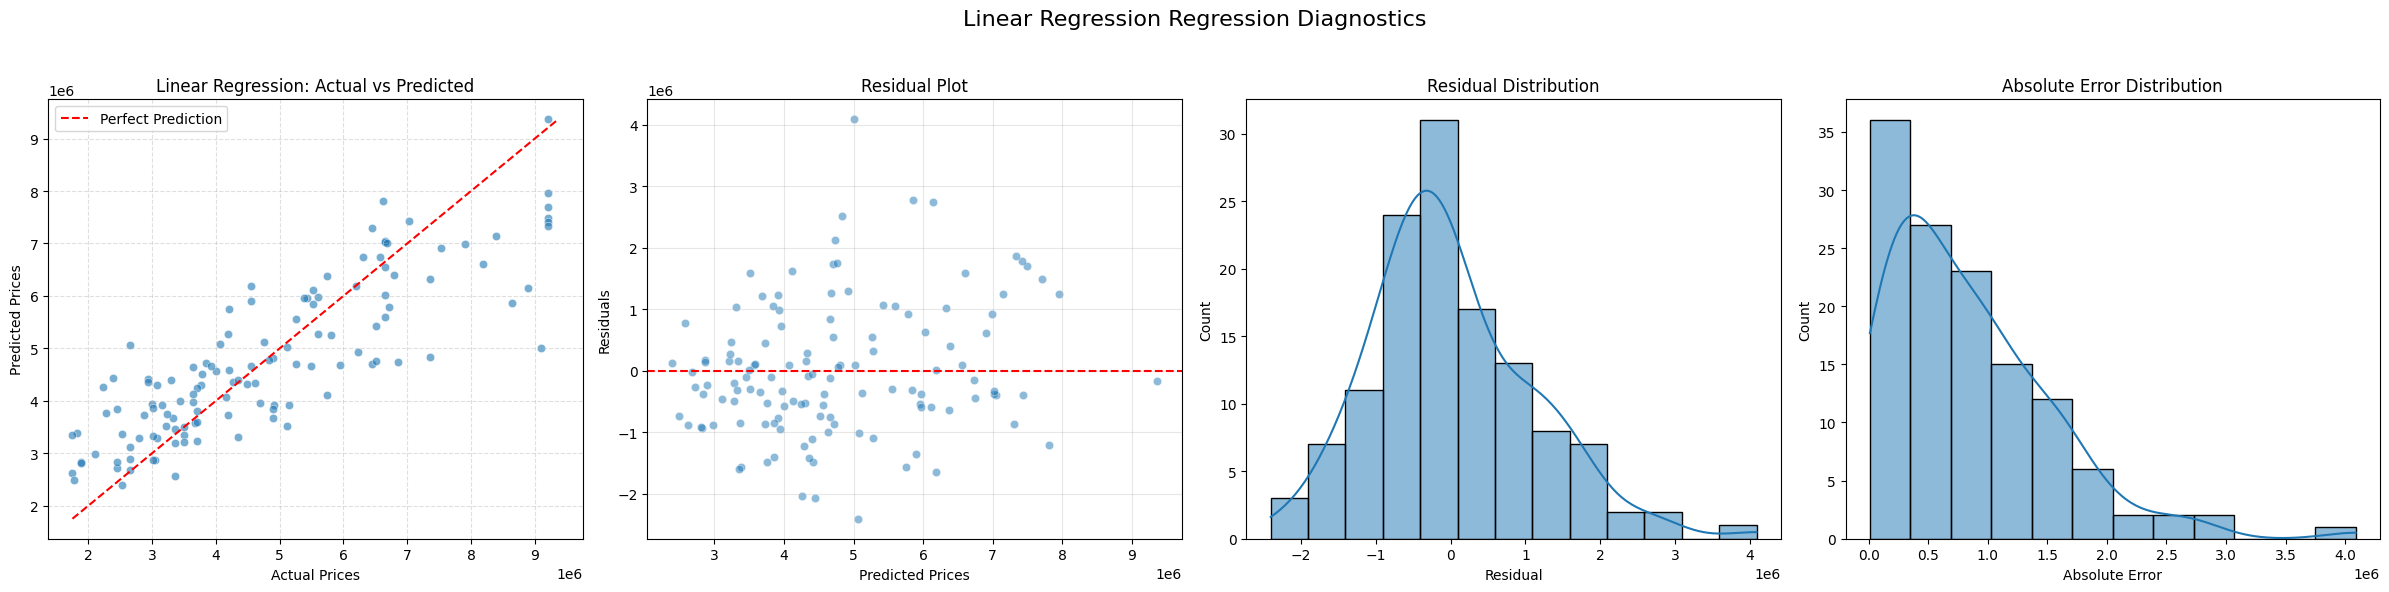

In [10]:
pred_linear = pd.read_csv("./models/predictions/linear_regression_predictions.csv")
plot_regression_diagnostics(pred_linear, "Linear Regression")


## Decision Tree

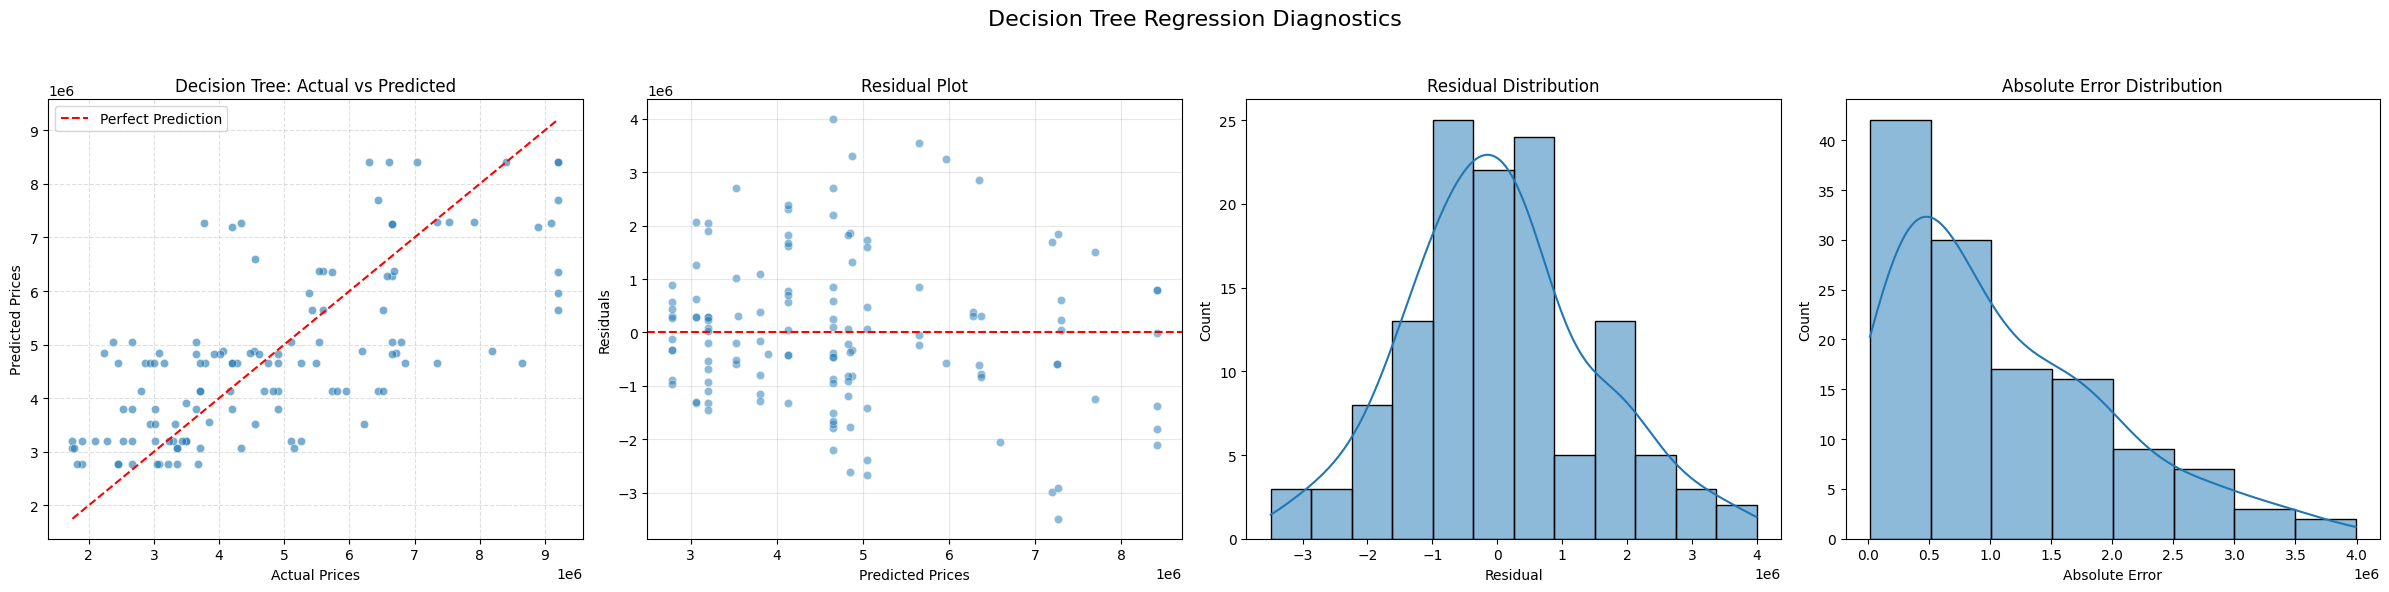

In [11]:
pred_decision_tree = pd.read_csv(
    "./models/predictions/decision_tree_predictions.csv"
)

plot_regression_diagnostics(pred_decision_tree, "Decision Tree")


## Random Forest

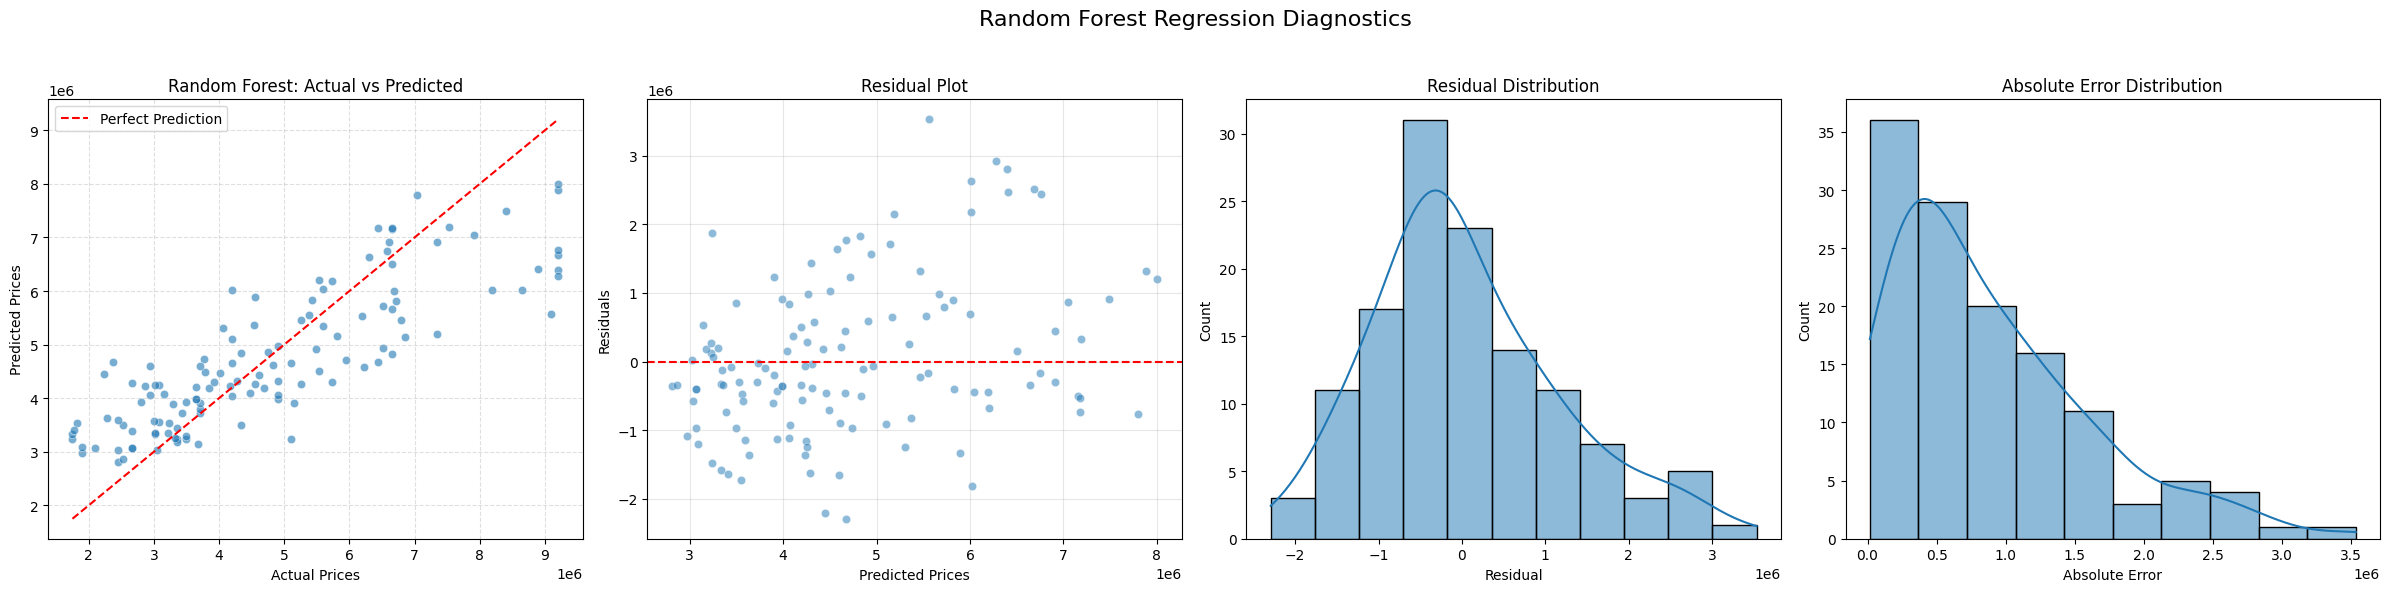

In [ ]:
pred_random_forest = pd.read_csv(
    "./models/predictions/random_forest_predictions.csv"
)
plot_regression_diagnostics(pred_random_forest, "Random Forest")


## Gradient Boost Model

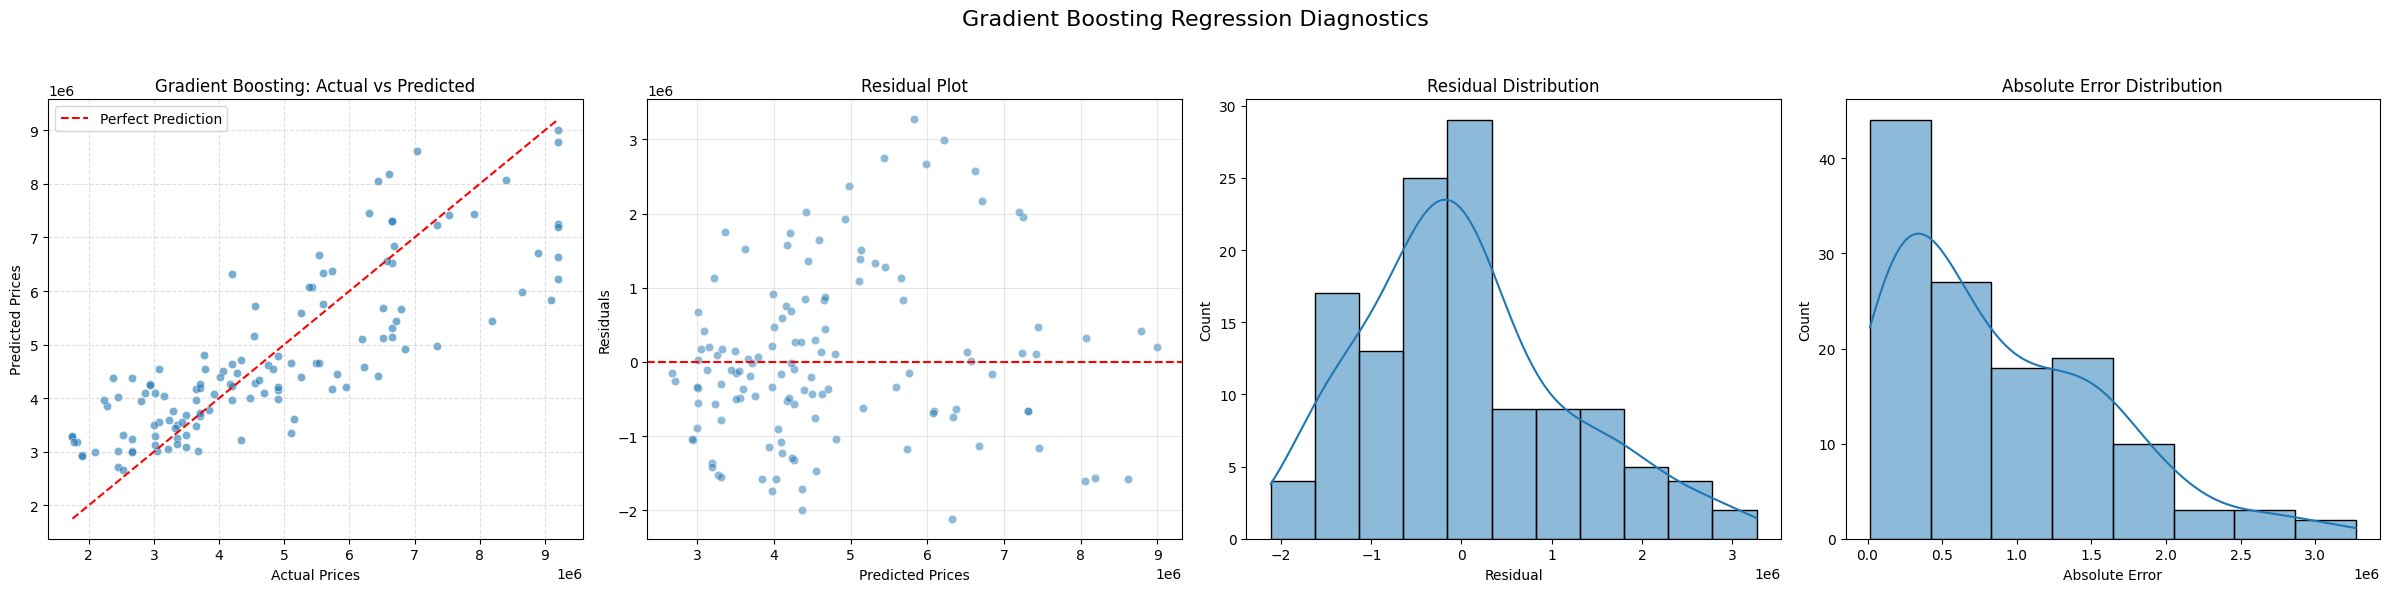

In [14]:
pred_random_forest = pd.read_csv(
    "./models/predictions/gradient_boosting_predictions.csv"
)

plot_regression_diagnostics(pred_random_forest, "Gradient Boosting")


## XGBoost Model

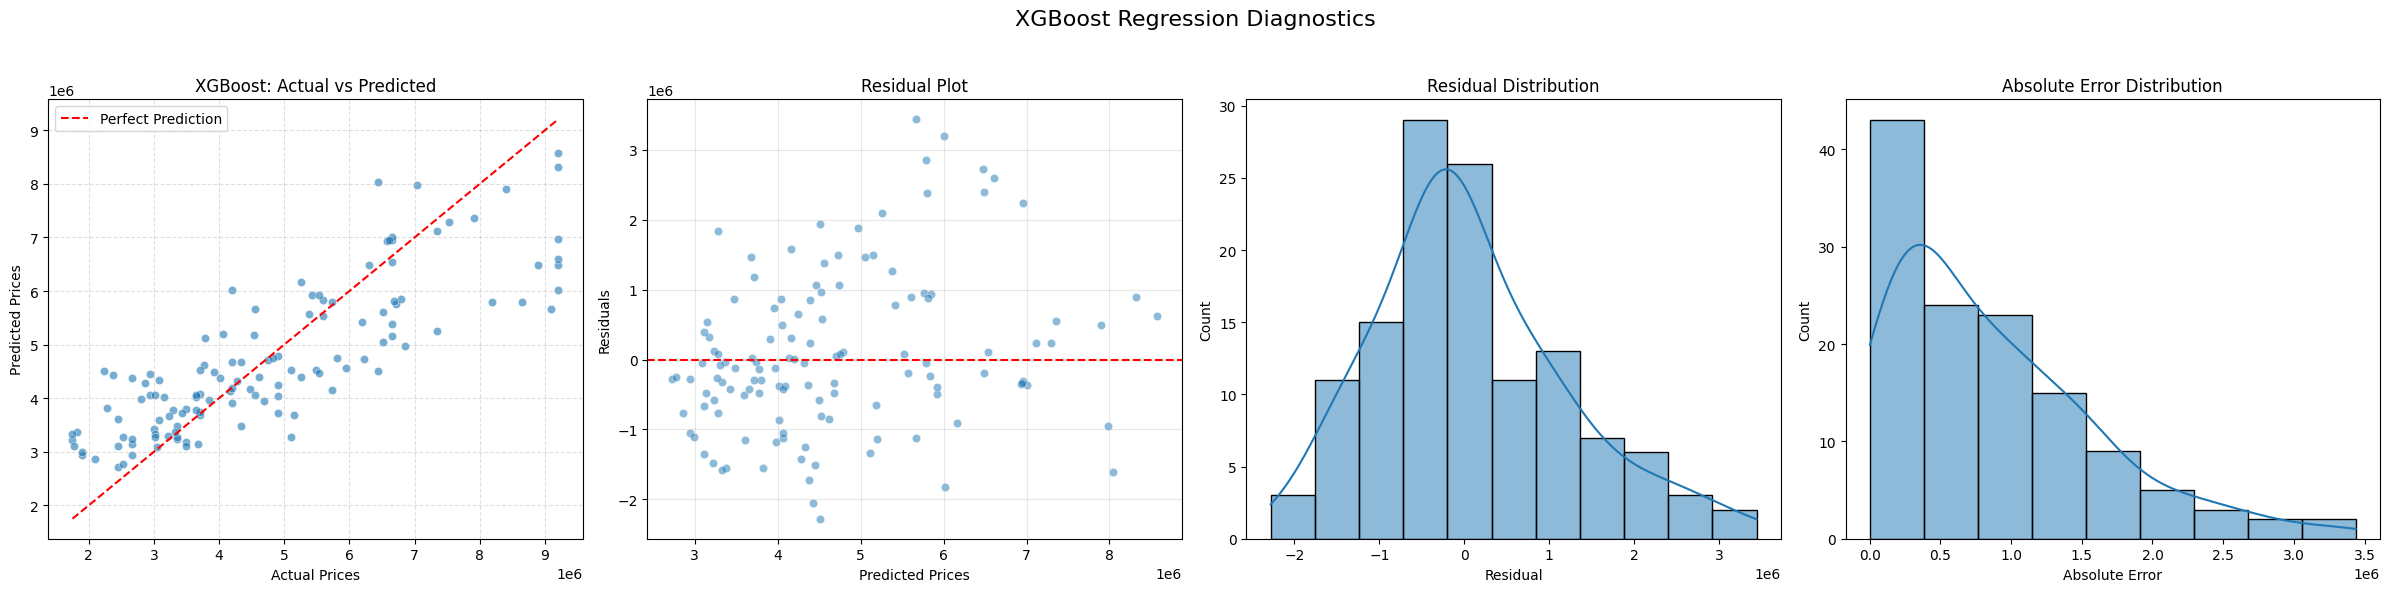

In [15]:
pred_xgboost = pd.read_csv(
    "./models/predictions/xgboost_predictions.csv"
)

plot_regression_diagnostics(pred_xgboost, "XGBoost")
